# 09. Dimensions and Bundles Analysis

This notebook analyzes:
1. Area-specific reforms (each of the 5 EFW dimensions)
2. Clean (single-area) vs bundled (multi-area) reforms
3. Which dimensions drive aggregate effects

**EFW Areas:**
1. Size of Government
2. Legal System & Property Rights
3. Sound Money
4. Freedom to Trade Internationally
5. Regulation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_CLEAN = PROJECT_ROOT / 'data/03_clean'
OUTPUT_FIGURES = PROJECT_ROOT / 'output/figures'
OUTPUT_TABLES = PROJECT_ROOT / 'output/tables'
OUTPUT_LOGS = PROJECT_ROOT / 'output/logs'

for d in [OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

# Parameters
K = 4
L = 6

# EFW Area names
EFW_AREAS = {
    1: 'Size of Government',
    2: 'Legal System & Property Rights',
    3: 'Sound Money',
    4: 'Freedom to Trade',
    5: 'Regulation',
}

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/gabrielsaco/Documents/GitHub/economic-freedom


## 1. Load Panel Data

In [2]:
panel = pd.read_parquet(DATA_CLEAN / 'panel_with_shocks.parquet')

print(f"Panel: {len(panel)} observations, {panel['iso3c'].nunique()} countries")

# Check area-specific reform variables
for area in range(1, 6):
    pos_col = f'reform_area{area}_pos_cd'
    neg_col = f'reform_area{area}_neg_cd'
    
    if pos_col in panel.columns:
        n_pos = panel[pos_col].sum()
        n_neg = panel[neg_col].sum()
        print(f"  Area {area} ({EFW_AREAS[area][:20]}): R+={n_pos:.0f}, R-={n_neg:.0f}")

Panel: 1815 observations, 165 countries
  Area 1 (Size of Government): R+=83, R-=39
  Area 2 (Legal System & Prope): R+=34, R-=17
  Area 3 (Sound Money): R+=111, R-=33
  Area 4 (Freedom to Trade): R+=88, R-=10
  Area 5 (Regulation): R+=60, R-=15


## 2. Build Area-Specific Stacked Datasets

In [3]:
def build_area_stacked(panel, area_num, sign='pos', K=2, L=4):
    """
    Build stacked event dataset for a specific EFW area.
    """
    event_col = f'reform_area{area_num}_{sign}_cd'
    
    if event_col not in panel.columns:
        print(f"  Column {event_col} not found")
        return None
    
    # Identify events
    events = panel[panel[event_col] == 1][['iso3c', 'year']].copy()
    events = events.rename(columns={'year': 'event_year'})
    
    if len(events) < 5:
        print(f"  Too few events for Area {area_num} ({sign}): {len(events)}")
        return None
    
    # Build stacked data
    treated_countries = set(events['iso3c'].unique())
    never_treated = set(panel['iso3c'].unique()) - treated_countries
    
    stacked_dfs = []
    
    for _, event in events.iterrows():
        iso = event['iso3c']
        event_year = event['event_year']
        
        window_start = event_year - K * 5
        window_end = event_year + L * 5
        cohort_id = f"{iso}_{event_year}_area{area_num}"
        
        # Treated
        treated_data = panel[
            (panel['iso3c'] == iso) &
            (panel['year'] >= window_start) &
            (panel['year'] <= window_end)
        ].copy()
        treated_data['treated'] = 1
        treated_data['cohort_id'] = cohort_id
        treated_data['event_time'] = (treated_data['year'] - event_year) // 5
        
        # Control (never-treated + not-yet-treated)
        later_treated = events[events['event_year'] > event_year]['iso3c'].unique()
        control_countries = never_treated | set(later_treated)
        
        control_data = panel[
            (panel['iso3c'].isin(control_countries)) &
            (panel['year'] >= window_start) &
            (panel['year'] <= window_end)
        ].copy()
        control_data['treated'] = 0
        control_data['cohort_id'] = cohort_id
        control_data['event_time'] = (control_data['year'] - event_year) // 5
        
        cohort_data = pd.concat([treated_data, control_data], ignore_index=True)
        stacked_dfs.append(cohort_data)
    
    if len(stacked_dfs) == 0:
        return None
    
    stacked = pd.concat(stacked_dfs, ignore_index=True)
    
    # Add outcome relative to t-1
    if 'ln_gdp_pc' in stacked.columns:
        base = stacked[stacked['event_time'] == -1][['cohort_id', 'iso3c', 'ln_gdp_pc']].copy()
        base = base.rename(columns={'ln_gdp_pc': 'ln_gdp_pc_base'})
        stacked = stacked.merge(base, on=['cohort_id', 'iso3c'], how='left')
        stacked['y_cumulative'] = stacked['ln_gdp_pc'] - stacked['ln_gdp_pc_base']
    
    return stacked

# Build stacked data for each area
area_stacked = {}

print("\nBuilding area-specific stacked datasets...")
for area in range(1, 6):
    print(f"\nArea {area} ({EFW_AREAS[area]}):")
    
    stacked_pos = build_area_stacked(panel, area, 'pos', K=K, L=L)
    stacked_neg = build_area_stacked(panel, area, 'neg', K=K, L=L)
    
    area_stacked[area] = {
        'positive': stacked_pos,
        'negative': stacked_neg
    }
    
    if stacked_pos is not None:
        print(f"  Positive: {len(stacked_pos)} obs, {stacked_pos['cohort_id'].nunique()} cohorts")
    if stacked_neg is not None:
        print(f"  Negative: {len(stacked_neg)} obs, {stacked_neg['cohort_id'].nunique()} cohorts")


Building area-specific stacked datasets...

Area 1 (Size of Government):
  Positive: 68673 obs, 83 cohorts
  Negative: 36755 obs, 39 cohorts

Area 2 (Legal System & Property Rights):
  Positive: 33511 obs, 34 cohorts
  Negative: 17903 obs, 17 cohorts

Area 3 (Sound Money):
  Positive: 81535 obs, 111 cohorts
  Negative: 30517 obs, 33 cohorts

Area 4 (Freedom to Trade):
  Positive: 75607 obs, 88 cohorts
  Negative: 10511 obs, 10 cohorts

Area 5 (Regulation):
  Positive: 54908 obs, 60 cohorts
  Negative: 15722 obs, 15 cohorts


## 3. Estimate Area-Specific Effects

In [4]:
def estimate_area_effects(stacked, K=2, L=4):
    """
    Estimate event study for area-specific data.
    """
    if stacked is None:
        return None
    
    df = stacked.dropna(subset=['y_cumulative']).copy()
    
    if len(df) < 100:
        return None
    
    # Create treatment interactions
    for k in range(-K, L+1):
        if k == -1:
            continue
        col = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        df[col] = ((df['treated'] == 1) & (df['event_time'] == k)).astype(int)
    
    # Demean
    df['cohort_country'] = df['cohort_id'] + '_' + df['iso3c']
    cc_means = df.groupby('cohort_country')['y_cumulative'].transform('mean')
    df['y_dm'] = df['y_cumulative'] - cc_means
    
    treat_cols = []
    for k in range(-K, L+1):
        if k == -1:
            continue
        col = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        treat_cols.append(col)
    
    for col in treat_cols:
        cc_mean = df.groupby('cohort_country')[col].transform('mean')
        df[col + '_dm'] = df[col] - cc_mean
    
    X = df[[c + '_dm' for c in treat_cols]].values
    X_const = np.column_stack([np.ones(len(df)), X])
    y = df['y_dm'].values
    
    model = OLS(y, X_const)
    fit = model.fit(cov_type='cluster', cov_kwds={'groups': df['iso3c']})
    
    estimates = {-1: {'coef': 0, 'se': 0}}
    for i, col in enumerate(treat_cols):
        if 'et_-' in col:
            k = -int(col.split('_')[2])
        else:
            k = int(col.split('_')[2].replace('p', ''))
        estimates[k] = {
            'coef': fit.params[i+1],
            'se': fit.bse[i+1],
        }
    
    return {
        'estimates': estimates,
        'n_obs': len(y),
        'n_cohorts': df['cohort_id'].nunique(),
        'n_clusters': df['iso3c'].nunique(),
    }

# Estimate for each area
area_results = {}

print("\nEstimating area-specific effects...")
for area in range(1, 6):
    print(f"\nArea {area} ({EFW_AREAS[area]}):")
    
    res_pos = estimate_area_effects(area_stacked[area]['positive'], K=K, L=L)
    res_neg = estimate_area_effects(area_stacked[area]['negative'], K=K, L=L)
    
    area_results[area] = {
        'positive': res_pos,
        'negative': res_neg
    }
    
    if res_pos:
        print(f"  Positive: {res_pos['n_obs']} obs, {res_pos['n_cohorts']} cohorts")
    else:
        print(f"  Positive: insufficient data")
    
    if res_neg:
        print(f"  Negative: {res_neg['n_obs']} obs, {res_neg['n_cohorts']} cohorts")
    else:
        print(f"  Negative: insufficient data")


Estimating area-specific effects...

Area 1 (Size of Government):
  Positive: 59491 obs, 83 cohorts
  Negative: 31840 obs, 39 cohorts

Area 2 (Legal System & Property Rights):
  Positive: 29718 obs, 34 cohorts
  Negative: 16155 obs, 17 cohorts

Area 3 (Sound Money):
  Positive: 72736 obs, 111 cohorts
  Negative: 24292 obs, 33 cohorts

Area 4 (Freedom to Trade):
  Positive: 63762 obs, 88 cohorts
  Negative: 9826 obs, 10 cohorts

Area 5 (Regulation):
  Positive: 48855 obs, 60 cohorts
  Negative: 13480 obs, 15 cohorts


## 4. Plot Area-Specific IRFs

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_areas_pos.pdf


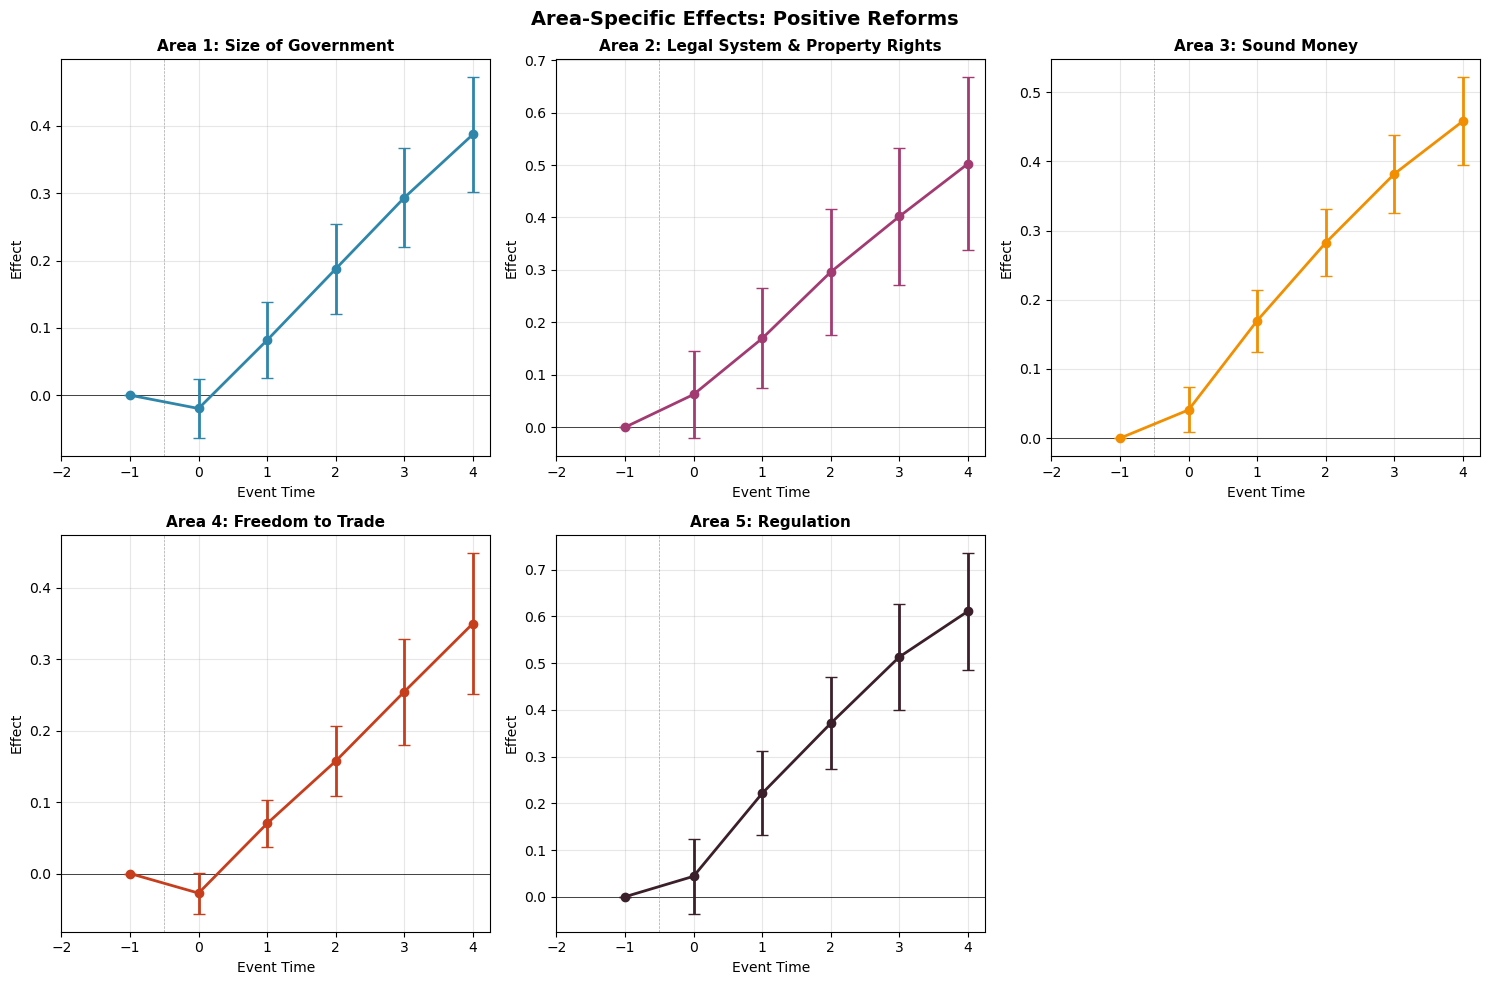

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_areas_neg.pdf


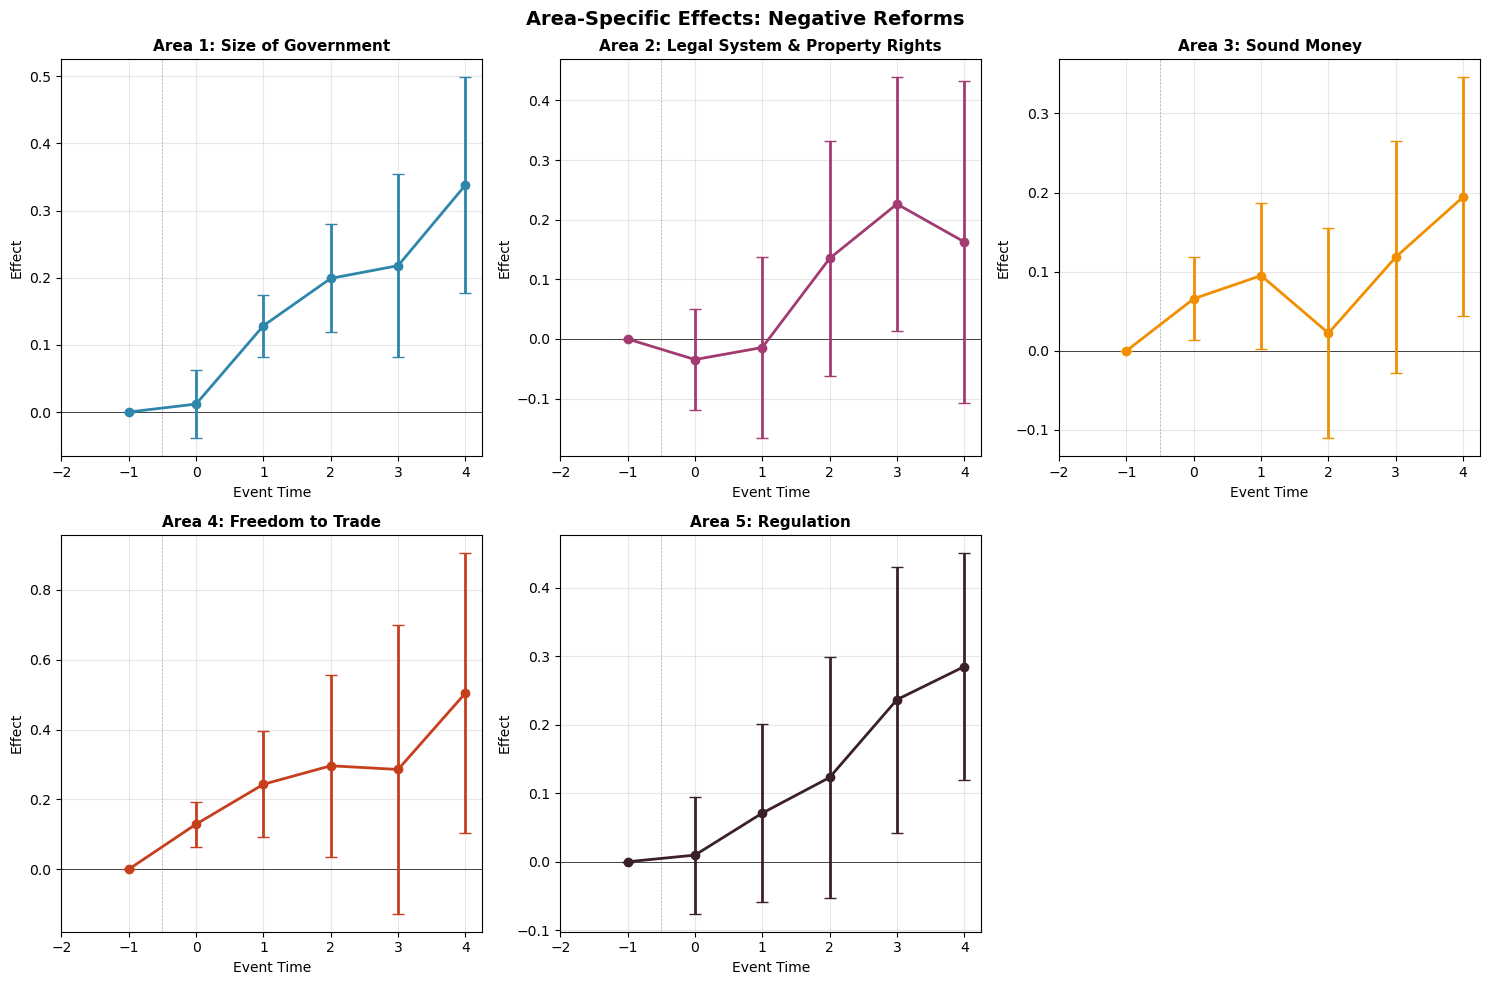

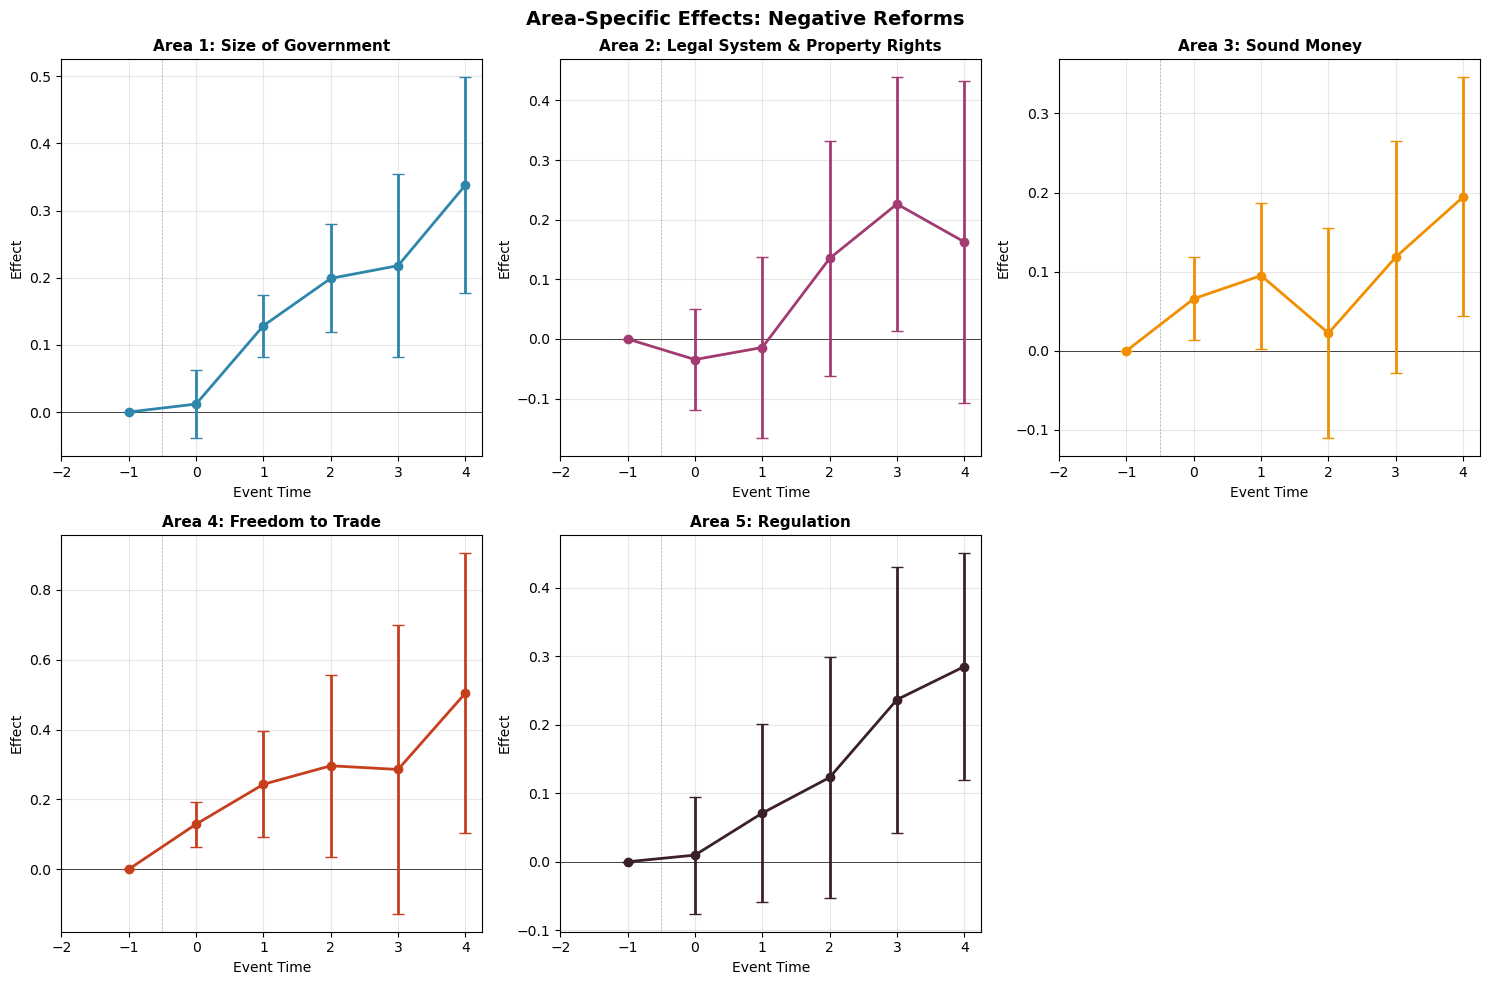

In [5]:
def plot_area_irfs(area_results, sign='positive', K=2, L=4, save_path=None):
    """
    Plot IRFs for all areas on the same figure.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    event_times = list(range(-K, L+1))
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
    
    for i, area in enumerate(range(1, 6)):
        ax = axes[i]
        res = area_results[area][sign]
        
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
        
        if res is None:
            ax.text(0.5, 0.5, 'Insufficient Data', 
                    transform=ax.transAxes, ha='center', fontsize=12)
        else:
            coefs = [res['estimates'].get(k, {}).get('coef', np.nan) for k in event_times]
            ses = [res['estimates'].get(k, {}).get('se', np.nan) for k in event_times]
            
            ax.errorbar(event_times, coefs,
                        yerr=[1.96*s if not np.isnan(s) else 0 for s in ses],
                        fmt='o-', color=colors[i], capsize=4, 
                        markersize=6, linewidth=2)
        
        ax.set_title(f'Area {area}: {EFW_AREAS[area]}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Event Time', fontsize=10)
        ax.set_ylabel('Effect', fontsize=10)
        ax.set_xticks(event_times)
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplot
    axes[5].axis('off')
    
    sign_label = 'Positive' if sign == 'positive' else 'Negative'
    fig.suptitle(f'Area-Specific Effects: {sign_label} Reforms', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

# Plot area IRFs
plot_area_irfs(area_results, sign='positive', K=K, L=L,
               save_path=OUTPUT_FIGURES / 'fig_irf_areas_pos.pdf')

plot_area_irfs(area_results, sign='negative', K=K, L=L,
               save_path=OUTPUT_FIGURES / 'fig_irf_areas_neg.pdf')

## 5. Comparative Area Effects (Bar Chart)

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_cumulative_by_area.pdf


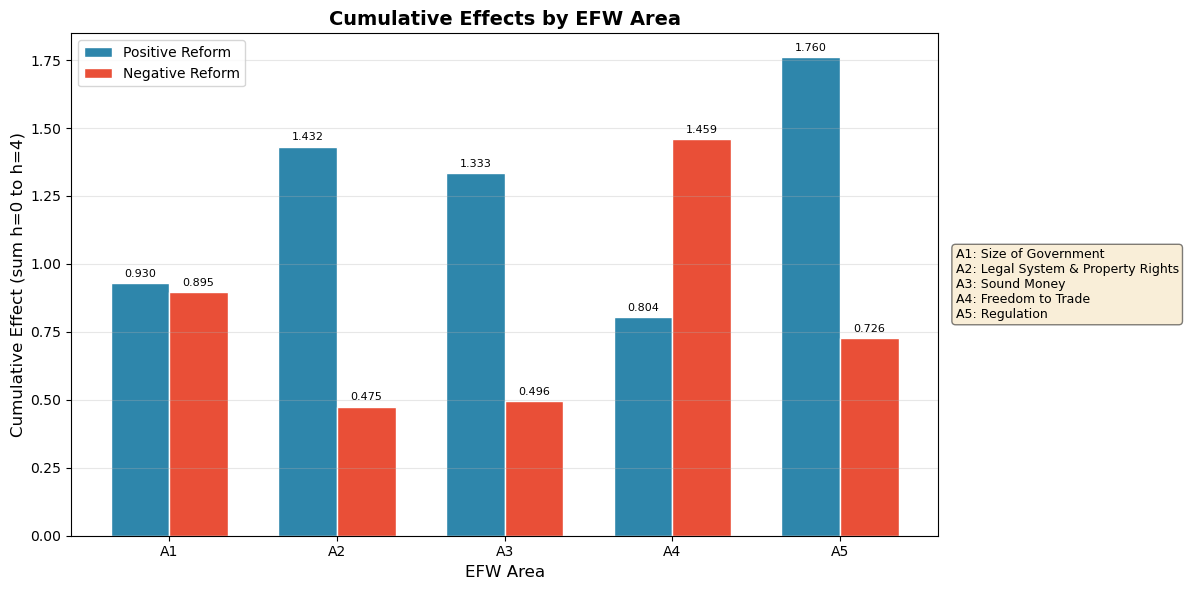

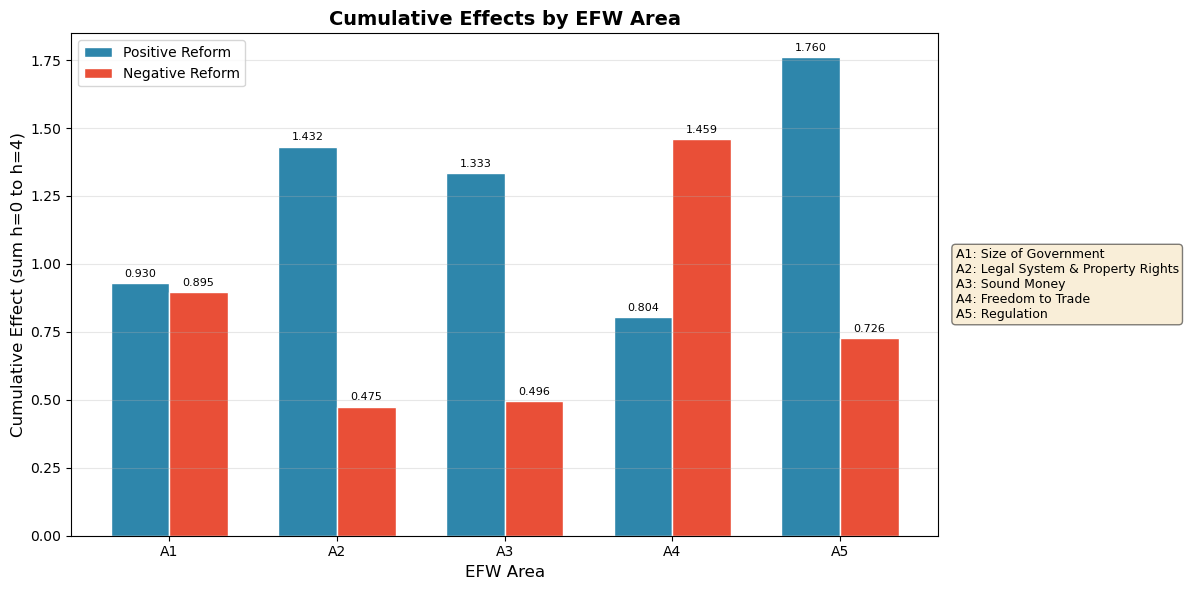

In [6]:
def plot_cumulative_by_area(area_results, K=2, L=4, save_path=None):
    """
    Bar chart comparing cumulative effects across areas.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    areas = list(range(1, 6))
    area_names = [EFW_AREAS[a] for a in areas]
    
    cumulative_pos = []
    cumulative_neg = []
    
    for area in areas:
        res_pos = area_results[area]['positive']
        res_neg = area_results[area]['negative']
        
        if res_pos:
            cum = sum([res_pos['estimates'].get(k, {}).get('coef', 0) for k in range(0, L+1)])
            cumulative_pos.append(cum)
        else:
            cumulative_pos.append(0)
        
        if res_neg:
            cum = sum([res_neg['estimates'].get(k, {}).get('coef', 0) for k in range(0, L+1)])
            cumulative_neg.append(cum)
        else:
            cumulative_neg.append(0)
    
    x = np.arange(len(areas))
    width = 0.35
    
    bars_pos = ax.bar(x - width/2, cumulative_pos, width, label='Positive Reform',
                      color='#2E86AB', edgecolor='white')
    bars_neg = ax.bar(x + width/2, cumulative_neg, width, label='Negative Reform',
                      color='#E94F37', edgecolor='white')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('EFW Area', fontsize=12)
    ax.set_ylabel('Cumulative Effect (sum h=0 to h=4)', fontsize=12)
    ax.set_title('Cumulative Effects by EFW Area', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'A{a}' for a in areas], fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars_pos:
        height = bar.get_height()
        if height != 0:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
    
    for bar in bars_neg:
        height = bar.get_height()
        if height != 0:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3 if height > 0 else -10), textcoords="offset points",
                        ha='center', va='bottom' if height > 0 else 'top', fontsize=8)
    
    # Add legend for area names
    area_legend = '\n'.join([f'A{a}: {EFW_AREAS[a]}' for a in areas])
    ax.text(1.02, 0.5, area_legend, transform=ax.transAxes, fontsize=9,
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

plot_cumulative_by_area(area_results, K=K, L=L,
                        save_path=OUTPUT_FIGURES / 'fig_cumulative_by_area.pdf')

## 6. Clean vs Bundled Reform Analysis

In [7]:
# Check bundle indicators
if 'is_clean_reform' in panel.columns and 'is_bundled_reform' in panel.columns:
    print("Bundle analysis:")
    print(f"  Clean reforms (single area): {panel['is_clean_reform'].sum():.0f}")
    print(f"  Bundled reforms (multi-area): {panel['is_bundled_reform'].sum():.0f}")
    
    # Distribution of number of areas affected
    if 'n_areas_shocked' in panel.columns:
        print("\nNumber of areas shocked:")
        print(panel[panel['n_areas_shocked'] > 0]['n_areas_shocked'].value_counts().sort_index())

Bundle analysis:
  Clean reforms (single area): 498
  Bundled reforms (multi-area): 282

Number of areas shocked:
n_areas_shocked
1    498
2    206
3     59
4     16
5      1
Name: count, dtype: int64


## 7. Summary Table

In [8]:
# Create summary table
summary_rows = []

for area in range(1, 6):
    res_pos = area_results[area]['positive']
    res_neg = area_results[area]['negative']
    
    row = {
        'Area': area,
        'Name': EFW_AREAS[area],
    }
    
    if res_pos:
        row['N_pos'] = res_pos['n_cohorts']
        row['Impact_pos'] = res_pos['estimates'].get(0, {}).get('coef', np.nan)
        row['Cum_pos'] = sum([res_pos['estimates'].get(k, {}).get('coef', 0) for k in range(0, L+1)])
    else:
        row['N_pos'] = 0
        row['Impact_pos'] = np.nan
        row['Cum_pos'] = np.nan
    
    if res_neg:
        row['N_neg'] = res_neg['n_cohorts']
        row['Impact_neg'] = res_neg['estimates'].get(0, {}).get('coef', np.nan)
        row['Cum_neg'] = sum([res_neg['estimates'].get(k, {}).get('coef', 0) for k in range(0, L+1)])
    else:
        row['N_neg'] = 0
        row['Impact_neg'] = np.nan
        row['Cum_neg'] = np.nan
    
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*80)
print("AREA-SPECIFIC EFFECTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Save as LaTeX
latex_table = summary_df.to_latex(index=False, float_format='%.4f')
table_path = OUTPUT_TABLES / 'tab_area_effects.tex'
with open(table_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ Saved table to {table_path}")


AREA-SPECIFIC EFFECTS SUMMARY
 Area                           Name  N_pos  Impact_pos  Cum_pos  N_neg  Impact_neg  Cum_neg
    1             Size of Government     83   -0.019765 0.929949     39    0.011840 0.895129
    2 Legal System & Property Rights     34    0.062461 1.431759     17   -0.034546 0.475281
    3                    Sound Money    111    0.040838 1.332701     33    0.065891 0.496383
    4               Freedom to Trade     88   -0.027422 0.804045     10    0.129064 1.458588
    5                     Regulation     60    0.043808 1.760325     15    0.009716 0.726044

✓ Saved table to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/tables/tab_area_effects.tex


## 8. Save Results

In [9]:
# Convert to JSON-serializable format
def convert_results(results):
    converted = {}
    for area, data in results.items():
        converted[area] = {}
        for sign, res in data.items():
            if res is None:
                converted[area][sign] = None
            else:
                converted[area][sign] = {
                    'n_obs': int(res['n_obs']),
                    'n_cohorts': int(res['n_cohorts']),
                    'n_clusters': int(res['n_clusters']),
                    'estimates': {
                        str(k): {
                            'coef': float(v['coef']) if not np.isnan(v['coef']) else None,
                            'se': float(v['se']) if not np.isnan(v['se']) else None,
                        }
                        for k, v in res['estimates'].items()
                    }
                }
    return converted

results_json = {
    'timestamp': datetime.now().isoformat(),
    'area_results': convert_results(area_results),
    'area_names': EFW_AREAS,
    'summary': summary_df.to_dict(orient='records'),
}

results_path = OUTPUT_LOGS / 'dimensions_bundles_results.json'
with open(results_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"✓ Saved results to {results_path}")

print("\n" + "="*60)
print("09_DIMENSIONS_BUNDLES COMPLETE")
print("="*60)

✓ Saved results to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/dimensions_bundles_results.json

09_DIMENSIONS_BUNDLES COMPLETE
